In [1]:
from datetime import date
from math import floor

import numpy as np
from parso.python.tree import Class
from pyexpat.errors import messages

from resources.libs import slowpandas as spd
import re
import math
import numpy as np

$$Score_t=Score_{t-1}+{Ge^{\varphi\pi^2}\cdot \frac{Points_{t}}{\sqrt{Points_{t-1}}}}$$

# Exercise 01
    Python Advance Basics

## Q1
You will need to practice string theory.

    1. Guns&Roses are back. Create a string with 10 back-slashes and print it. FIND AS MANY WAYS POSSIBLE

In [2]:
print('\\\\\\\\\\\\\\\\\\\\')
print('\\'*10)
print(''.join(['\\']*10))

\\\\\\\\\\
\\\\\\\\\\
\\\\\\\\\\


    2. Print math.pi with 0,1,2,3,...,15 decimal points. 
        a. 2 LINES OF CODE ONLY
        b. NO MOD
        c. NO ROUND

In [3]:
a=str(math.pi)
print(a[0:15])

3.1415926535897


    3. We must do slow stuff! Call spd.do_slow_stuff.
        a. Print progress in percentage with 2 decimal points
        b. NO NEW LINES IN OUTPUT

In [4]:
def output_func(x):
    print(round(x*100,2),end='')
spd.do_slow_stuff(output_func)

0.02.04.06.08.010.012.014.016.018.020.022.024.026.028.030.032.034.036.038.040.042.044.046.048.050.052.054.056.058.060.062.064.066.068.070.072.074.076.078.080.082.084.086.088.090.092.094.096.098.0100.0

## Q2
It's women's day! So lets deal with Objects.

    1. Write a Date class
        a. you can save only milliseconds as data member
        b. these operators must work: < > == != + - ...
        c. you can access fields using a key: date['day'], date['month']

In [5]:
class Date:
    def __init__(self, mil):
        self.time = mil
    
    def __add__(self, other):
        return Date(self.time + other.time)
    
    def __eq__(self, other):
        return self.time == other.time
    
    def __lt__(self, other):
        return self.time < other.time
    
    def __gt__(self, other):
        return self.time > other.time

    def __ne__(self, other):
        return self.time != other.time
    
    def __add__(self, other):
        return Date(self.time + other.time)
    
    def __getitem__(self, key):
        if key == 'day':
            return math.ceil(self.time/(24*60*60*1000))
        if key == 'month':
            return math.ceil(self.time/(24*60*60*1000*30))

    2. Create a list of 240 dates, one date for each hour since 10 days ago.
        a. ONE LINE OF CODE ALLOWED

In [6]:
x=[Date(x) for x in np.arange(-24*10*60*60*1000,0,60*60*1000)]


    3. Filter your list with these queries:
        a. Skip a day
        b. Take only the 8'th day
        c. Take odd hours only
        
        *** ONE LINE OF CODE ALLOWED FOR EACH QUERY***

In [7]:
a = [i for i in x if i['day']!=-1]
b = [i for i in x if i['day']==8]
c = [i for i in x if np.floor(i.time/1000/60/60)%2==1]

## Q3
A top secret agent got his hand on the file 'big_brother.txt'. You will need to help him understand what the file is about.

    1. Read the file located in the 'data' directory and print it. Is it OK?

In [8]:
with open('resources/data/big_brother.txt', 'r') as f:
    content = f.read()
    print(content)

UnicodeDecodeError: 'charmap' codec can't decode byte 0x9f in position 41: character maps to <undefined>

    2. That isn't ok. Our intell suggest that this file was taken from the crazy latins which known for decoding things with 'ISO-8859-1'. FIX THE DATA
        Hint: Is the data unicode? try type('hello') vs type(u'hello')  

In [9]:
with open('resources/data/big_brother.txt', 'r', encoding='utf-8',errors='igonre') as f:
    content = f.readlines()#
    content=[x.encode('latin-1').decode('utf-8') for x in content]
len(content)

3420

    3. A gold mine! Your next task is to turn this data into entities using python classes.
        Hint: classes are NOT DataFrame - you need User, Message, Date ...

In [11]:
import datetime
class User():
    def __init__(self,name):
        self.name=name

    def __str__(self):
        return self.name

class Messege():
    def __init__(self,msg,user,date):
        self.msg=msg
        self.user=user
        self.date=date
a='2/4/16, 14:40'
class Date():
    def __init__(self,datetime_txt):
        date_txt,time_txt=str.split(datetime_txt,",")
        self.month,self.day,self.year=str.split(date_txt,'/')
        self.hour,self.minute= str.split(time_txt,':')
        self.day,self.month,self.year=int(self.day),int(self.month),int(self.year)
        self.hour,self.minute= int(self.hour),int(self.minute)

    def to_datetime(self):
        return datetime.datetime(
            year=2000 + self.year if self.year < 100 else self.year,
            month=self.month,
            day=self.day,
            hour=self.hour,
            minute=self.minute
        )

    def __str__(self):
        return(str(self.day)+'/'+str(self.month)+'/'+str(self.year)+'  '+str(self.hour)+":"+str(self.minute))
dates=[]
users=[]
messeges=[]
weird_messeges=[]
for i in range(len(content)):
    try:

        datetime_txt=content[i].split('-')[0]
        dates.append(Date(datetime_txt))
        user_name,messege_txt=content[i].split('-')[1].split(':')
        users.append(User(user_name))
        messeges.append(Messege(messege_txt,users[-1],dates[-1]))
    except:
        weird_messeges.append(content[i])
messeges

 ...]

    4. Classy. Now turn your classes into a SlowDataFrame. Oh! Not before you save them to a file first... 
        *** ALL DATA IN ONE FILE ***

In [12]:
df=spd.SlowDataFrame([[x.msg.strip(),x.user.name,x.date.to_datetime()] for x in messeges],columns=['msg','name','date'])
df

,msg,name,date
0,<Media omitted>,עמיאל מייזליש,2015-11-05 15:07:00
1,👍,ספי כהן,2015-11-05 15:23:00
2,"interesting dataset, to say the least...",עמיאל מייזליש,2015-11-07 21:35:00
3,<Media omitted>,גד בנרם,2015-11-07 21:47:00
4,בחדר כושר . פיזיקאים יש הסבר?,גד בנרם,2015-11-07 21:49:00
...,...,...,...
3101,מספר המקומות מוגבל,ספי כהן,2016-03-07 20:26:00
3102,"אעדכן, אבל בגדול לא צריכה להיות בעיה",תומר גלנטי,2016-03-07 20:30:00
3103,באיזו שעה זה מסתיים?,תומר גלנטי,2016-03-07 21:09:00
3104,<Media omitted>,Nir Malbin,2016-03-07 21:11:00


    5. Extract date features: day, month, year, hour, min, sec
        ONLY USING 'apply' - ONE LINE OF CODE PER FEATURE
         *** NOTE: slowpandas is quite slow... you MUST output the progress ***

In [13]:
df['year']=[x.year for x in df["date"]]
df['month']=[x.month for x in df["date"]]
df['day']=[x.day for x in df["date"]]
df['hour']=[x.hour for x in df["date"]]
df['min']=[x.minute for x in df["date"]]
df

,msg,name,date,year,month,day,hour,min
0,<Media omitted>,עמיאל מייזליש,2015-11-05 15:07:00,2015,11,5,15,7
1,👍,ספי כהן,2015-11-05 15:23:00,2015,11,5,15,23
2,"interesting dataset, to say the least...",עמיאל מייזליש,2015-11-07 21:35:00,2015,11,7,21,35
3,<Media omitted>,גד בנרם,2015-11-07 21:47:00,2015,11,7,21,47
4,בחדר כושר . פיזיקאים יש הסבר?,גד בנרם,2015-11-07 21:49:00,2015,11,7,21,49
...,...,...,...,...,...,...,...,...
3101,מספר המקומות מוגבל,ספי כהן,2016-03-07 20:26:00,2016,3,7,20,26
3102,"אעדכן, אבל בגדול לא צריכה להיות בעיה",תומר גלנטי,2016-03-07 20:30:00,2016,3,7,20,30
3103,באיזו שעה זה מסתיים?,תומר גלנטי,2016-03-07 21:09:00,2016,3,7,21,9
3104,<Media omitted>,Nir Malbin,2016-03-07 21:11:00,2016,3,7,21,11


    6. Plot a graph for each user showing his activity hour-wise (mean)
        *** ALL GRAPHS IN ONE NOTEBOOK CELL ***

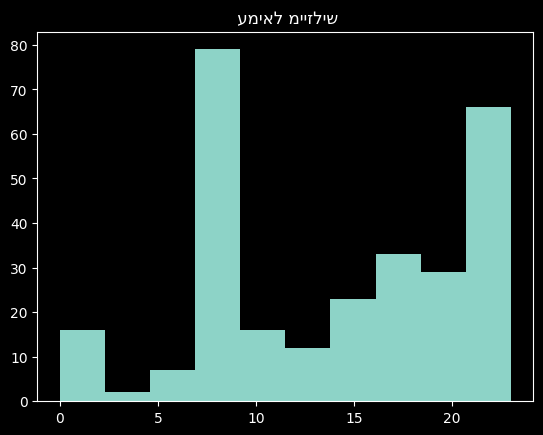

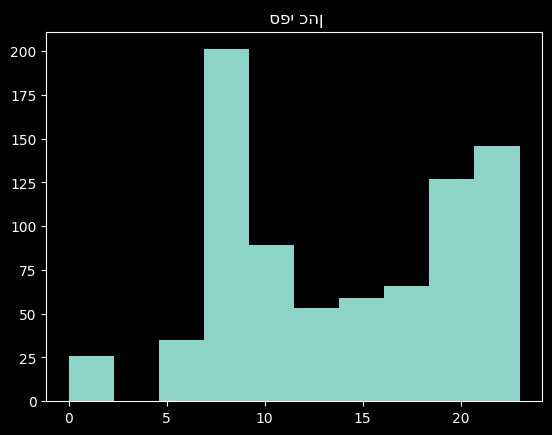

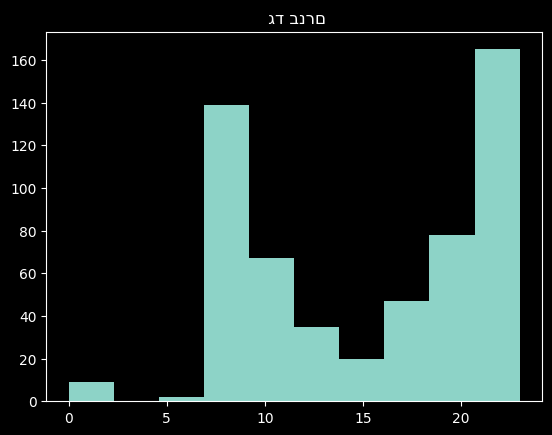

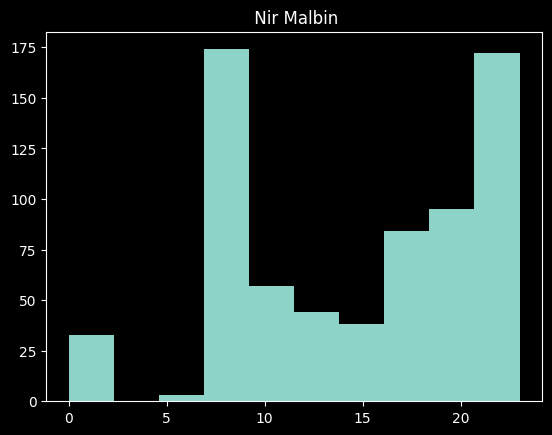

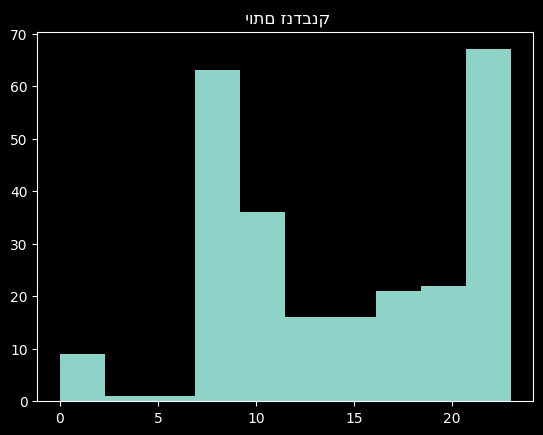

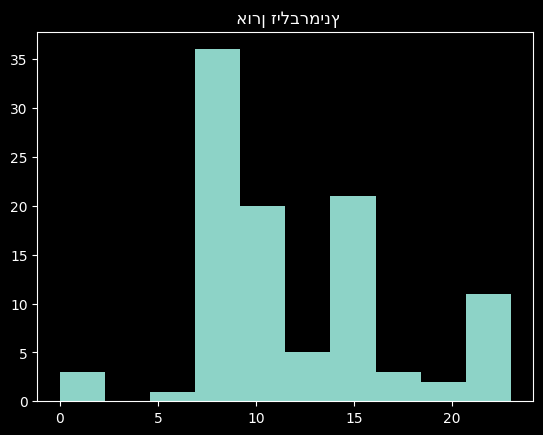

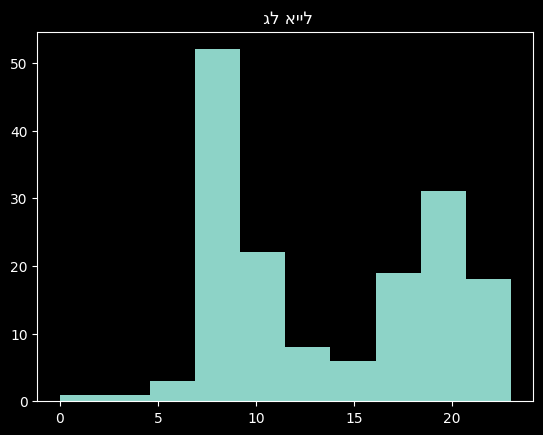

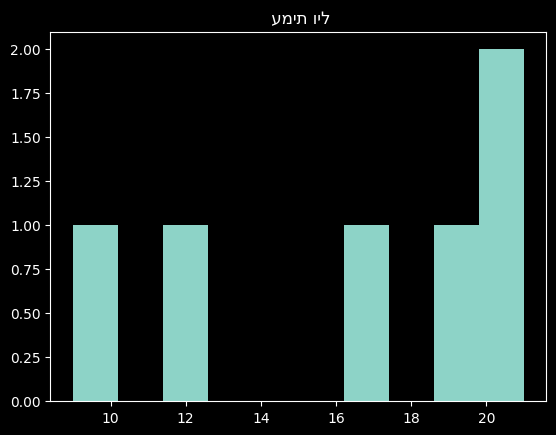

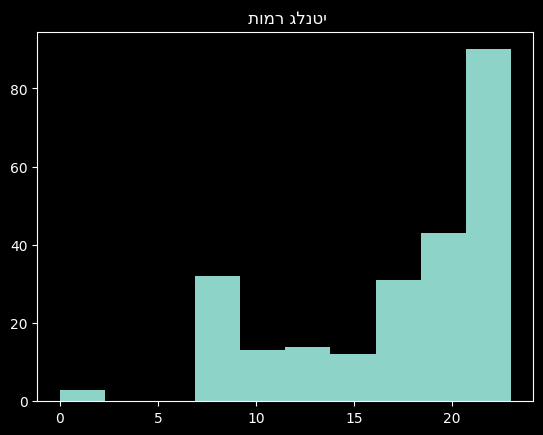

In [23]:
import matplotlib.pyplot as plt

for name in df['name'].unique():
    x=df.iloc[df['name'] == name,:]['hour']
    plt.hist(x)
    plt.title(name)
    plt.show()

    7. What is the 10 most common used words for each user?
        *** NO EXTERNAL LIBS ALLOWED ***

In [54]:
for name in df['name'].unique():
    x=df.iloc[df['name'] == name,:]['msg']
    words=[word for msg in x for word in msg.split()]
    word_num={}
    for word in words:
        if word not in word_num.keys():
            word_num[word]=0
        word_num[word]+=1
    tenth_highest_word_rate=sorted(word_num.values())[-10]
    print(name)
    print([word for word in word_num.keys() if word_num[word]>=tenth_highest_word_rate])

 עמיאל מייזליש
['<Media', 'omitted>', 'של', '👍🏻', 'אני', 'חחח', 'לי', 'לא', 'זה', 'על', 'את']
 ספי כהן
['😂', 'אני', 'את', '<Media', 'omitted>', 'של', 'זה', 'לא', 'עם', 'יש', 'לי']
 גד בנרם
['<Media', 'omitted>', 'יש', 'לא', 'אני', 'של', 'את', 'הוא', 'זה', 'על']
 Nir Malbin
['זה', 'לא', 'של', 'אני', '<Media', 'omitted>', 'את', 'לי', 'יש', 'עם']
 יותם זנדבנק
['👍🏻', 'אני', 'את', 'של', '😂😂', '😂', '<Media', 'omitted>', 'כן', 'לי']
 אורן זילברמינץ
['👍🏻', 'לי', 'אני', 'גם', 'זה', 'טוב', 'חופש', 'מאחר', 'משהו', 'היום', 'חח']
 גל אייל
['<Media', 'omitted>', 'לא', 'אני', 'את', 'לי', 'אבל', 'מה', 'של', 'זה']
 עמית ויל
['כל', 'הכבוד', 'גל!!', '🎉💪', 'לעמיאל', 'וגל', 'את', 'עמיאל', 'ראיתי', 'כקצין', 'אז', 'אני', 'מחכה', 'לתמונה', 'של', 'גל', 'קצין', 'ואז', 'אלך', 'מפה', '😊', 'תמונה!', 'הופהההה', '🎉', 'טוב', 'זהו,', 'ביי', 'לקבוצה', 'המדורית.', 'בהצלחה', 'לקצינים', 'הטריים,', 'טיסה', 'נעימה', 'לטסים', 'לחו"ל,', 'לא', 'לנוח', 'יותר', 'מידי', 'על', 'הפוף', 'החדש', ';)', 'תמשיכו', 'להיות', 'תותחים', '😘'

In [60]:
def logfunc(f):
    def wrapped_func(*args):
        print("starting function")
        a=f(*args)
        print("function finished")
        return a
    return wrapped_func
@logfunc
def add(a,b):
    return(a+b)
a=add(2,5)
print(a)

starting function
function finished
7
